# Sparse low-rank matrix factorization $X=UV$
## Problem

$$\min\limits_{U,V} \frac{1}{2}\|UV-A\|^2 + \|U\|_1 + \|V\|_1 + \iota_{C_1}(U) + \iota_{C_2}(V)$$

with $C_1$ and $C_2$ nuclear norm balls.

In [16]:
import numpy as np
import fw_functions as fw

In [17]:
class SparseLRMF(fw.ObjectiveFunction):
    # X must be of the form [U V] where U is nxp and V is pxm
    def __init__(self, A, n):
        self.A = A
        self.n = n
    
    def evaluate(self, X):
        """
        Objective function: 1/2 * ||UV - A||_2^2 where X = [U; V.T]
        """
        U = X[:self.n]
        V = X[self.n:].T
        return 0.5 * np.linalg.norm(U @ V - self.A, ord='fro')**2
    
    def gradient(self, X):
        U = X[:self.n]
        V = X[self.n:].T
        
        # U grad
        U_grad = (U @ V - self.A) @ V.T
        
        # V grad
        V_grad = U.T @ (U @ V - self.A)
        
        # Combine U_grad and V_grad
        grad = np.vstack((U_grad, V_grad.T))
        
        return grad
    
    def linear_operator(self, X):
        return X
    
    def linear_operator_adjoint(self, X):
        return X
    
    def minimal_norm_selection(self, X):
        U = X[:self.n]
        V = X[self.n:].T

        U_mns = fw.l1_minimal_norm_selection(U)
        V_mns = fw.l1_minimal_norm_selection(V)

        # Combine U_mns and V_mns
        mns = np.vstack((U_mns, V_mns.T))
        
        return mns

In [18]:
# Create an instance of the Sparse low-rank matrix factorization

np.random.seed(0)

# Generate random data
n = int(1e2)
p = int(1e2)
m = int(1e2)
A = np.random.rand(n,m)

U0 = 0.1 * (2 * np.random.rand(n, p) - 1)
V0 = 0.1 * (2 * np.random.rand(p, m) - 1)
X0 = np.vstack((U0, V0.T))

# Create the LMO function
U_rad = np.sqrt(np.linalg.norm(A, ord='nuc'))
V_rad = np.sqrt(np.linalg.norm(A, ord='nuc'))
U_constraint_set = 'nuclear_norm_ball'
V_constraint_set = 'nuclear_norm_ball'
U_lmo_fn = fw.create_lmo(U_rad, U_constraint_set)
V_lmo_fn = fw.create_lmo(V_rad, V_constraint_set)
def lmo_fn(gradient):
    U_grad = gradient[:n]
    V_grad = gradient[n:].T
    U_lmo = U_lmo_fn(U_grad)
    V_lmo = V_lmo_fn(V_grad)
    lmo_result = np.vstack((U_lmo, V_lmo.T))
    return lmo_result

# Create the prox function
lambda1 = 1.0
lambda2 = 1.0
def prox_fn(X, beta):
    U = X[:n]
    V = X[n:].T
    U_prox = fw.soft_thresh(U, beta * lambda1)
    V_prox = fw.soft_thresh(V, beta * lambda2)
    prox_result = np.vstack((U_prox, V_prox.T))
    return prox_result

# Initialize the objective
objective_fn = SparseLRMF(A, n)
objective_type = 'lipschitz'

# Create an instance of the FrankWolfe class
Sparselrmf = fw.FrankWolfe(objective_fn, lmo_fn, prox_fn, objective_type)

print(np.linalg.norm(A, ord='nuc'))
print(np.linalg.norm(U, ord='nuc'))
print(np.linalg.norm(V, ord='nuc'))

291.47484268883204
49.5088295817368
48.95150778964733


In [19]:
# Run the algorithm
Sparselrmf.run(X0)

Frank-Wolfe Progress: 100%|██████████| 100/100 [00:02<00:00, 44.88it/s]


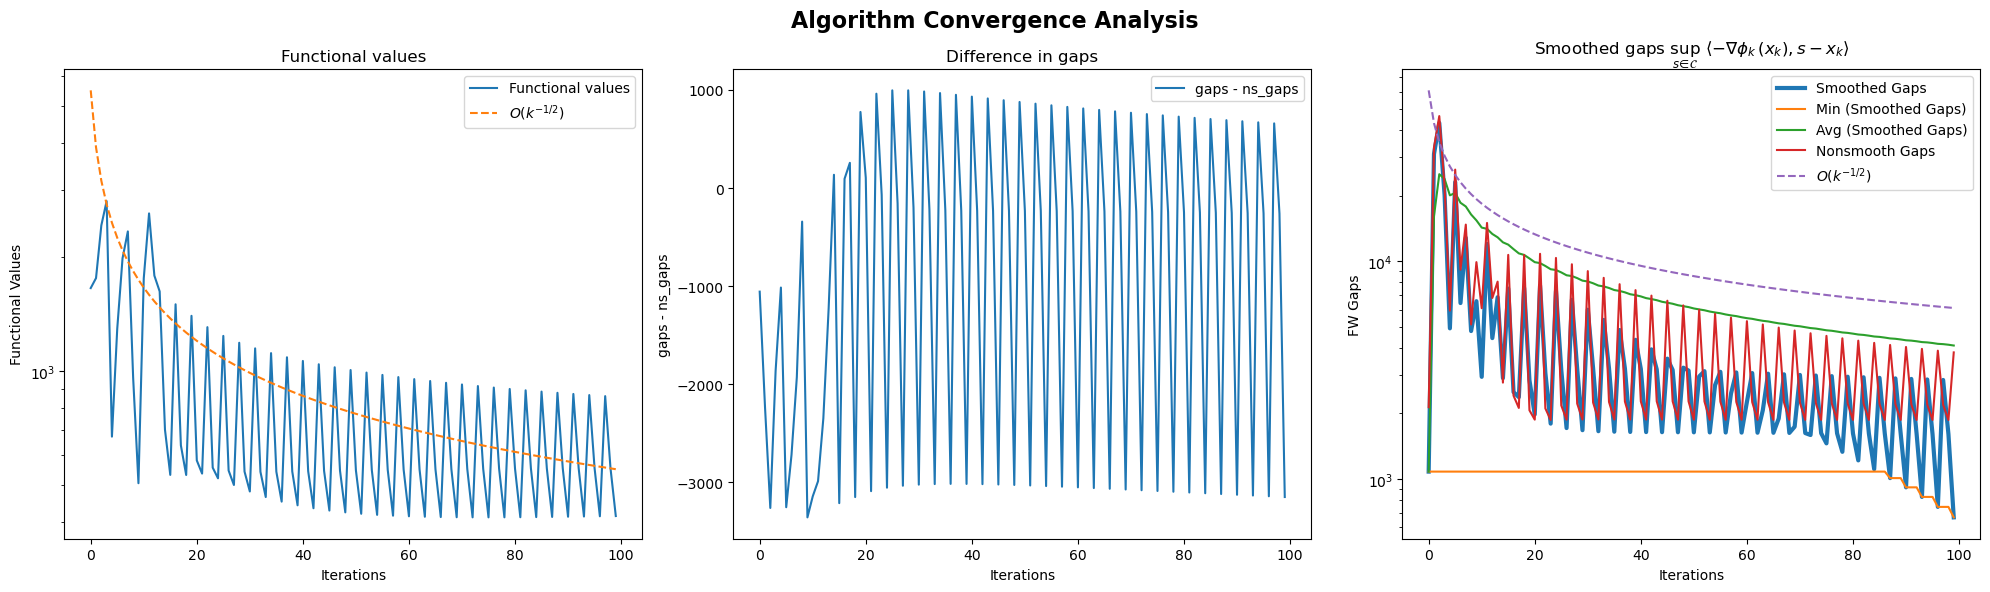

In [20]:
# Plot the convergence results
Sparselrmf.plot_convergence()

In [21]:
# UNIT TESTS FOR THE STACKING OPERATIONS


testerU = np.random.rand(n, p)
testerU[0][0] = 1
testerV = np.random.rand(p, m)
testerV[0][1] = 1
testerX = np.vstack((testerU, testerV.T))

# Test that testerX[:n] matches testerU
print("Testing testerX[:n] == testerU:")
if np.allclose(testerX[:n], testerU):
    print("PASS: testerX[:n] matches testerU")
else:
    print("FAIL: testerX[:n] does not match testerU")

# Test that testerX[n:].T matches testerV
print("\nTesting testerX[n:].T == testerV:")
if np.allclose(testerX[n:].T, testerV):
    print("PASS: testerX[n:].T matches testerV")
else:
    print("FAIL: testerX[n:].T does not match testerV")

# def lmo_fn(gradient):
#     U_grad = gradient[:n]
#     V_grad = gradient[n:].T
#     print("U_grad:")
#     print(U_grad)
#     print("V_grad:")
#     print(V_grad)
#     U_lmo = U_lmo_fn(U_grad)
#     V_lmo = V_lmo_fn(V_grad)
#     print("U_lmo:")
#     print(U_lmo)
#     print("V_lmo:")
#     print(V_lmo)
#     lmo_result = np.vstack((U_lmo, V_lmo.T))
#     return lmo_result

lmo_fn_output = lmo_fn(testerX)
lmo_fn_U = lmo_fn_output[:n]
lmo_fn_V = lmo_fn_output[n:].T
U_lmo_fn_output = U_lmo_fn(testerU)
V_lmo_fn_output = V_lmo_fn(testerV)

print("Testing lmo_fn_U == U_lmo_fn_output:")
if np.allclose(lmo_fn_U, U_lmo_fn_output):
    print("PASS: lmo_fn_U matches U_lmo_fn_output")
else:
    print("FAIL: lmo_fn_U does not match U_lmo_fn_output")

print("\nTesting lmo_fn_V == V_lmo_fn_output:")
if np.allclose(lmo_fn_V, V_lmo_fn_output):
    print("PASS: lmo_fn_V matches V_lmo_fn_output")
else:
    print("FAIL: lmo_fn_V does not match V_lmo_fn_output")

beta = 1.0  # Choose an appropriate value for beta

prox_fn_output = prox_fn(testerX, beta)
prox_fn_U = prox_fn_output[:n]
prox_fn_V = prox_fn_output[n:].T
U_prox_fn_output = fw.soft_thresh(testerU, beta * lambda1)
V_prox_fn_output = fw.soft_thresh(testerV, beta * lambda2)

print("Testing prox_fn_U == U_prox_fn_output:")
if np.allclose(prox_fn_U, U_prox_fn_output):
    print("PASS: prox_fn_U matches U_prox_fn_output")
else:
    print("FAIL: prox_fn_U does not match U_prox_fn_output")

print("\nTesting prox_fn_V == V_prox_fn_output:")
if np.allclose(prox_fn_V, V_prox_fn_output):
    print("PASS: prox_fn_V matches V_prox_fn_output")
else:
    print("FAIL: prox_fn_V does not match V_prox_fn_output")

Testing testerX[:n] == testerU:
PASS: testerX[:n] matches testerU

Testing testerX[n:].T == testerV:
PASS: testerX[n:].T matches testerV
Testing lmo_fn_U == U_lmo_fn_output:
PASS: lmo_fn_U matches U_lmo_fn_output

Testing lmo_fn_V == V_lmo_fn_output:
PASS: lmo_fn_V matches V_lmo_fn_output
Testing prox_fn_U == U_prox_fn_output:
PASS: prox_fn_U matches U_prox_fn_output

Testing prox_fn_V == V_prox_fn_output:
PASS: prox_fn_V matches V_prox_fn_output
